# COGS 108 - EDA Checkpoint

## Authors

**Sindhu Dhulipala**: Analysis, Visualization (sleep duration histogram), Data curation, Writing – original draft

**Anwesha Mohanty**: Analysis, Visualization (physical activity histogram and correlation heatmap), Data analysis

**Akshitaa Balasai**: Visualization (box plot of sleep distribution), Analysis

**Ryan Kasem**: Data curation, Exploratory Data Analysis setup, Writing – review & editing

**Hasnain Farishta**: Data curation, Exploratory Data Analysis setup, Writing – review & editing

# Research Question

How does the total duration of daily physical activity affect sleep duration in adults aged 16 and older?

In this study, sleep quality is defined based on whether an individual’s average sleep duration meets medically recommended levels for adult functional health.

- Sleep duration is calculated using the total minutes asleep recorded in the dataset.
- Values are evaluated relative to standard adult sleep recommendations (approximately **7–9 hours per night**).



## Background and Prior Work

Sleep plays an important role in overall health because it helps the brain and body function properly each day. Getting enough sleep supports memory, concentration, metabolism, and general productivity. On the other hand, not getting enough sleep can lead to problems such as weakened immunity, mood changes, and mental health concerns. Since sleep affects so many parts of daily life, researchers often study what habits might improve or worsen sleep.

Sleep quality can mean different things, but in this project it is defined specifically as sleep duration, or how many hours a person sleeps. Previous research shows that consistently short sleep duration is linked to higher risks of weight gain, heart disease, stroke, anxiety, and depression.<sup>1</sup> Because of these risks, it is useful to understand which behaviors are connected to sleeping longer or shorter amounts of time.

Several lifestyle factors may influence sleep duration, including diet, screen use, and physical activity.<sup>2</sup> Physical activity is especially important because it affects both energy levels and the body’s natural sleep cycle. Studies suggest that people who exercise regularly, especially through daily movement or cardiovascular activity, tend to sleep longer and more consistently than those who are inactive.<sup>2</sup> This suggests that an active routine may support healthier sleep patterns.

For example, a study of undergraduate students in China found that students who exercised less and spent more time on screens before bed reported worse sleep outcomes.<sup>3</sup> This supports the idea that daily activity levels may be connected to how long people sleep. Building on this idea, this project will examine how the total duration of daily physical activity relates to sleep duration in adults aged 16 and older. Other factors such as age, gender, occupation, BMI, and blood pressure will also be considered to better understand the relationship between activity and sleep.

# Hypothesis


**Hypothesis**

We hypothesize that average sleep duration on weekdays (in minutes per night) will be shorter for those with higher BMI, advancing age, and higher blood pressure than for those with more favorable values of these variables. Specifically, we hypothesize that those who are classified as overweight or obese will have shorter average sleep duration on weekdays than those who have a normal BMI.

We also hypothesize that physical activity will be positively related to sleep duration. Those who accumulate fewer total minutes of physical activity per week will have shorter average sleep duration than those who accumulate the recommended 150 minutes per week. Furthermore, we hypothesize that sleep duration will vary by gender and occupation category, especially for those in more sedentary or stressful occupations.

**Rationale**

Sleep duration (in minutes per night) is affected by both physical health and daily lifestyle factors. A higher BMI is commonly associated with health issues like sleep apnea and breathing disturbances that can lead to lower overall sleep duration. As people grow older, their sleep patterns can become more fragmented, leading to lower overall sleep duration per night. High blood pressure can be an indicator of stress or other health issues that can disrupt sleep.

Physical activity can help promote healthier sleep patterns by controlling energy levels and the body’s natural sleep cycle. People who are more active on a weekly basis may have longer sleep duration than people who are less active. By analyzing sleep in minutes per night and activity in minutes per week, we can see if these factors are significantly related to sleep duration.

## Data

### Data overview

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- run once after cloning the repo

import sys
sys.path.append('./modules')

import get_data

# Use the direct CDC file paths (these work properly with requests)
datafiles = [
    {
        "url": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/SLQ_J.XPT?download",
        "filename": "SLQ_J.XPT"
    },
    {
        "url": "https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/PAQ_J.XPT?download",
        "filename": "PAQ_J.XPT"
    }
]

get_data.get_raw(datafiles, destination_directory="data/00-raw/")

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  2.83it/s]

Successfully downloaded: SLQ_J.XPT


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  3.23it/s]

Successfully downloaded: PAQ_J.XPT


# Dataset #1

**Dataset Name:**  
NHANES 2017–2018 Sleep Disorders Questionnaire (SLQ_J)

**Link to the Dataset:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SLQ_J.htm

**Number of Observations:**  
6,161 participants  

The SLQ_J file includes 6,161 individuals aged 16 years and older who completed the sleep questionnaire during the 2017–2018 NHANES cycle. Because NHANES uses a complex, multistage probability sampling design, these data are nationally representative of the civilian, non-institutionalized U.S. population. The 6,161 records represent all respondents in this cycle who provided sleep questionnaire data prior to merging or cleaning procedures.

**Number of Variables:**  
11 variables  

The dataset contains the following variables:

- **SEQN** – Respondent sequence number (unique participant ID)
- **SLQ300** – Usual sleep time on weekdays/workdays
- **SLQ310** – Usual wake time on weekdays/workdays
- **SLQ320** – Usual sleep time on weekends/non-workdays
- **SLQ330** – Usual wake time on weekends/non-workdays
- **SLD012** – Usual sleep duration on weekdays (hours)
- **SLD013** – Usual sleep duration on weekends (hours)
- **SLQ040** – Ever told by a doctor that you have a sleep disorder
- **SLQ050** – Trouble sleeping
- **SLQ060** – Ever told by a doctor that you have sleep apnea
- **SLQ070** – Snoring frequency

For this project, we focus primarily on the sleep timing and sleep duration variables (SLQ300–SLQ330, SLD012, and SLD013).

**Description of Variables Most Relevant to This Project:**

Although the dataset contains 11 variables, our analysis centers on sleep timing and duration patterns.

Primary variables include:

- **Weekday Bedtime (SLQ300)** – Usual time participant goes to sleep on weekdays/workdays (clock time).
- **Weekday Wake Time (SLQ310)** – Usual time participant wakes up on weekdays/workdays.
- **Weekend Bedtime (SLQ320)** – Usual time participant goes to sleep on weekends/non-workdays.
- **Weekend Wake Time (SLQ330)** – Usual time participant wakes up on weekends/non-workdays.

Using these timing variables, we derive:

- Weekday sleep duration (hours)
- Weekend sleep duration (hours)
- Difference between weekday and weekend sleep timing (indicator of social jet lag / circadian misalignment)

We also analyze:

- **SLD012** – Self-reported weekday sleep duration (hours per night)
- **SLD013** – Self-reported weekend sleep duration (hours per night)

Sleep duration is reported in **hours per night**.

For adults:
- 7–9 hours → Recommended healthy sleep range
- Less than 7 hours → Associated with increased risk of cardiovascular disease, obesity, diabetes, cognitive impairment, and mortality
- Less than 5–6 hours → Considered very short sleep and may indicate elevated health risk
- Greater than 9–10 hours → May also be associated with adverse health outcomes

Large differences between weekday and weekend sleep timing may reflect social jet lag, which has been linked to metabolic and mental health risks.

**Shortcomings of the Dataset:**

1. **Self-Reported Sleep Measures**  
All sleep measures are self-reported, which may introduce recall bias and rounding error (for example, reporting 10:00 PM instead of 9:47 PM). Self-reported sleep duration typically overestimates true sleep compared to objective measures such as actigraphy or wearable sleep trackers. The dataset does not measure sleep quality, awakenings, restfulness, or sleep stages.

2. **Missing and Uncertain Responses**  
Some responses include “Don’t Know,” “Refused,” or placeholder values. These were recoded as NaN during cleaning. Removing incomplete responses may slightly affect representativeness.

3. **Time Conversion**  
Sleep duration was originally reported in hours and converted to minutes for alignment with the physical activity dataset. Biologically implausible values (less than or equal to 0 or greater than 24 hours) were removed during cleaning to ensure accuracy and consistency.


In [3]:
import pandas as pd
import numpy as np

# ⚠️ IMPORTANT:
# Change this base_path to match YOUR computer's file location
# Each group member must update this to their own data folder.

base_path = "/Users/sindhudhulipala/Documents/COGS_sleep_project/data/00-raw/"

# Load only needed columns from sleep dataset
sleep_df = pd.read_sas(
    base_path + "SLQ_J.XPT.txt",
    format="xport"
)[["SEQN", "SLD012", "SLD013"]]

# Replace SAS missing value code with NaN
sleep_df = sleep_df.replace(5.397605e-79, np.nan)

# Rename columns for clarity
sleep_df = sleep_df.rename(columns={
    "SEQN": "participant_id",
    "SLD012": "weekday_sleep_hours",
    "SLD013": "weekend_sleep_hours"
})

print("Sleep dataset shape:", sleep_df.shape)
sleep_df.head()


Sleep dataset shape: (6161, 3)


,participant_id,weekday_sleep_hours,weekend_sleep_hours
0,93705.0,8.0,8.0
1,93706.0,10.5,11.5
2,93708.0,8.0,8.0
3,93709.0,7.0,6.5
4,93711.0,7.0,9.0


# Dataset #2

**Dataset Name:**  
National Health and Nutrition Examination Survey Physical Activity Questionnaire (PAQ_J)

**Link to the Dataset:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.xpt  

**Dataset Description Page:**  
https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.htm  

**Number of Observations:**  
5,856 participants  

**Number of Variables:**  
17 variables (analysis uses 2)

The NHANES Physical Activity Questionnaire (PAQ_J) provides measures of physical activity patterns among U.S. adults. The questionnaire includes variables measuring weekly physical activity such as minutes and number of days performing both moderate- and vigorous-intensity activity. By combining moderate and vigorous activity minutes, participants can be categorized as sedentary, insufficiently active, or meeting recommended public health guidelines.

Although the dataset contains 17 total variables describing physical activity frequency and duration, this project focuses specifically on two measures:

- **PAD615 – Vigorous Physical Activity Minutes**  
  Reports the number of minutes per week participants engage in vigorous-intensity activities. These activities substantially increase breathing or heart rate (e.g., running, cycling, heavy labor).

- **PAQ620 – Moderate Physical Activity Minutes**  
  Reports the number of minutes per week participants engage in moderate-intensity activities. These activities moderately increase breathing or heart rate (e.g., brisk walking, light labor, household tasks).

From these two variables, we calculate:

- **Total Physical Activity Minutes = Vigorous Minutes + Moderate Minutes**

Physical activity is measured in **minutes per week**. Public health guidelines recommend that adults perform at least **150 minutes per week** of moderate-intensity activity (or equivalent). Values below 150 minutes indicate low or insufficient activity levels, while values substantially above 150 minutes indicate highly active individuals.

**Shortcomings of the Dataset:**

1. **Self-Reported Data**  
   All activity measures are self-reported survey responses. Participants may overestimate or underestimate their activity levels due to recall bias or social desirability bias. Self-reported activity often exceeds objectively measured activity from wearable devices.

2. **Short-Term Reporting**  
   The questionnaire reflects a typical recent week rather than long-term activity patterns. Factors such as illness, travel, work demands, or seasonal changes may temporarily influence reported activity.

3. **Missing or Uncertain Responses**  
   Some responses include missing or uncertain values that require cleaning. Removing incomplete observations may slightly reduce representativeness.

4. **Population Coverage**  
   NHANES represents the non-institutionalized U.S. population. Hospitalized individuals, active-duty military personnel, and long-term care residents are excluded, which may slightly bias national activity estimates.

5. **No Frequency Distribution Across Days**  
   The dataset reports total weekly minutes but does not specify how activity is distributed across days. For analysis purposes, daily activity may be estimated by dividing weekly minutes by 7; however, this assumes activity is evenly distributed. In reality, some participants may concentrate activity into one or two days, which could affect sleep outcomes differently.


In [4]:
# ============================================================
# LOAD + CLEAN NHANES PHYSICAL ACTIVITY DATA (PAQ_J)
# ============================================================

import pandas as pd
import numpy as np

# ⚠️ UPDATE THIS PATH IF NEEDED
BASE_PATH = "/Users/sindhudhulipala/Documents/COGS_sleep_project/data/00-raw/"
# Each team member should update this to their own data folder

# Load only relevant columns
activity_df = pd.read_sas(
    BASE_PATH + "PAQ_J.XPT.txt",
    format="xport"
)[["SEQN", "PAD615", "PAQ620"]]

# Replace SAS missing value code
activity_df = activity_df.replace(5.397605e-79, np.nan)

# Rename columns
activity_df = activity_df.rename(columns={
    "SEQN": "participant_id",
    "PAD615": "vigorous_minutes_week",
    "PAQ620": "moderate_minutes_week"
})

# Remove negative or implausible values
activity_df = activity_df[
    (activity_df["vigorous_minutes_week"] >= 0) &
    (activity_df["moderate_minutes_week"] >= 0)
].copy()

# Create total physical activity variable
activity_df["total_activity_minutes_week"] = (
    activity_df["vigorous_minutes_week"] +
    activity_df["moderate_minutes_week"]
)

# Create guideline indicator (150 min per week threshold)
activity_df["meets_activity_guidelines"] = np.where(
    activity_df["total_activity_minutes_week"] >= 150, 1, 0
)

print("Activity dataset shape:", activity_df.shape)
activity_df.head()


Activity dataset shape: (1381, 5)


,participant_id,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
5,93712.0,420.0,1.0,421.0,1
8,93715.0,600.0,1.0,601.0,1
14,93723.0,60.0,1.0,61.0,0
23,93738.0,480.0,1.0,481.0,1
26,93743.0,360.0,1.0,361.0,1


# Merging the Sleep and Physical Activity Datasets

The purpose of merging the NHANES Sleep Questionnaire (SLQ_J) and the Physical Activity Questionnaire (PAQ_J) datasets is to examine the relationship between sleep patterns and physical activity levels among U.S. adults. Our research question investigates whether differences in physical activity are associated with variations in weekday and weekend sleep duration.

The sleep dataset provides measures of weekday and weekend sleep duration, allowing us to calculate total sleep minutes and differences between weekday and weekend sleep (an indicator of social jet lag). The physical activity dataset provides weekly minutes of moderate and vigorous activity, which can be combined to determine total physical activity levels and whether individuals meet public health guidelines.

By merging the datasets on the unique participant identifier (SEQN), we ensure that sleep and activity data correspond to the same individuals. This allows us to directly analyze whether more physically active individuals tend to sleep longer, have more consistent sleep schedules, or exhibit different sleep patterns compared to less active individuals.

Merging the datasets is essential because analyzing them separately would not allow us to assess individual-level associations between activity and sleep. 

In [5]:
# ============================================================
# MERGING PHYSICAL ACTIVITY AND SLEEP DATASETS
# ============================================================

# ---------- 1. Clean Sleep Data Further ----------

# Remove biologically impossible sleep values (must be >0 and <=24 hours)
sleep_df = sleep_df[
    (sleep_df["weekday_sleep_hours"] > 0) &
    (sleep_df["weekday_sleep_hours"] <= 24) &
    (sleep_df["weekend_sleep_hours"] > 0) &
    (sleep_df["weekend_sleep_hours"] <= 24)
].copy()

# Convert sleep hours to minutes
sleep_df["weekday_sleep_minutes"] = sleep_df["weekday_sleep_hours"] * 60
sleep_df["weekend_sleep_minutes"] = sleep_df["weekend_sleep_hours"] * 60

# Calculate difference between weekend and weekday sleep (social jet lag)
sleep_df["sleep_difference_minutes"] = (
    sleep_df["weekend_sleep_minutes"] -
    sleep_df["weekday_sleep_minutes"]
)

# ---------- 2. Ensure Activity Data Is Clean ----------

activity_df = activity_df.copy()

# Replace missing values with 0 (no reported activity)
activity_df["vigorous_minutes_week"] = activity_df["vigorous_minutes_week"].fillna(0)
activity_df["moderate_minutes_week"] = activity_df["moderate_minutes_week"].fillna(0)

# Recalculate total activity
activity_df["total_activity_minutes_week"] = (
    activity_df["vigorous_minutes_week"] +
    activity_df["moderate_minutes_week"]
)

# ---------- 3. Merge Datasets ----------

# Merge on participant ID (inner join keeps only participants in both datasets)
final_df = pd.merge(
    sleep_df,
    activity_df,
    on="participant_id",
    how="inner"
)

# ---------- 4. Final Dataset Cleanup ----------

# Drop any remaining rows with missing key variables
final_df = final_df.dropna(subset=[
    "weekday_sleep_minutes",
    "weekend_sleep_minutes",
    "total_activity_minutes_week"
])

print("Final merged dataset shape:", final_df.shape)
final_df.head()


Final merged dataset shape: (1363, 10)


,participant_id,weekday_sleep_hours,weekend_sleep_hours,weekday_sleep_minutes,weekend_sleep_minutes,sleep_difference_minutes,vigorous_minutes_week,moderate_minutes_week,total_activity_minutes_week,meets_activity_guidelines
0,93712.0,7.5,9.0,450.0,540.0,90.0,420.0,1.0,421.0,1
1,93715.0,5.0,5.0,300.0,300.0,0.0,600.0,1.0,601.0,1
2,93723.0,6.0,7.0,360.0,420.0,60.0,60.0,1.0,61.0,0
3,93738.0,7.0,7.5,420.0,450.0,30.0,480.0,1.0,481.0,1
4,93743.0,5.5,9.5,330.0,570.0,240.0,360.0,1.0,361.0,1


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Distribution of Sleep Duration

To better understand the sleep patterns in our dataset, we first examine the distribution of sleep duration among participants. 
The NHANES sleep dataset records the number of hours individuals report sleeping on weekdays and weekends. 
Understanding the distribution of sleep duration helps identify common sleep patterns and detect unusually short or long sleep durations. 
Since recommended sleep for adults is approximately 7–9 hours per night, this visualization allows us to see how closely the sample follows these guidelines.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


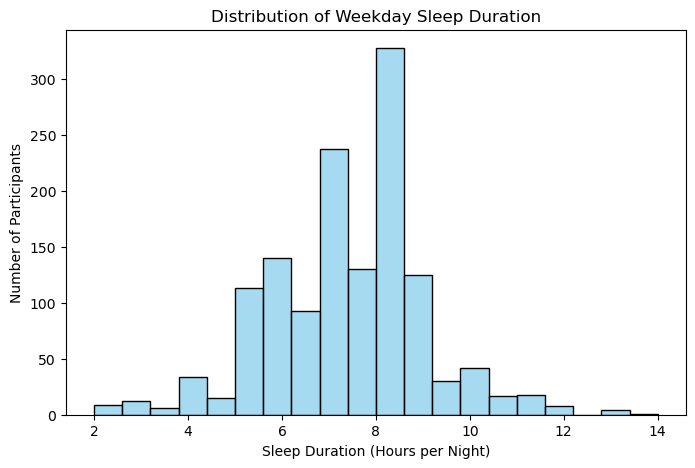

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(final_df["weekday_sleep_minutes"]/60, bins=20, color="skyblue", edgecolor="black")

plt.title("Distribution of Weekday Sleep Duration")
plt.xlabel("Sleep Duration (Hours per Night)")
plt.ylabel("Number of Participants")

plt.show()

From the histogram, it is evident that most people sleep between 6 and 8 hours on weekdays. This is somewhat consistent with recommendations for adult sleep duration, although it is also evident that some people are sleeping fewer than 7 hours per night. There are also some people sleeping more than 9 hours per night. This will be useful in determining whether physical activity is associated with long or short sleep durations.

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics


This project uses publicly available data from the National Health and Nutrition Examination Survey (NHANES) 2017–2018 cycle, conducted by the Centers for Disease Control and Prevention (CDC). The data are fully anonymized and do not contain any personally identifiable information. Participants’ identities are protected, and the data were collected under strict ethical and privacy standards. Because of this, privacy risks are minimal. The datasets are being used strictly for academic purposes.

The goal of this analysis is to explore statistical relationships between sleep duration and physical activity patterns, not to make medical claims, provide treatment recommendations, or establish causation. All findings will be presented at the population level. We will avoid overgeneralizing results or suggesting that certain demographic characteristics such as age, gender, or body measurements directly determine sleep outcomes.

We also recognize that sleep and health-related measures are influenced by many complex factors, including genetics, environment, lifestyle, and socioeconomic conditions. Any associations found in the data will be discussed carefully to avoid stigmatizing or stereotyping individuals or groups. The intention is to understand patterns, not to assign blame or make assumptions.

Throughout the project, all data cleaning steps, transformations, and analytical decisions will be clearly documented to ensure transparency and integrity. Any limitations, such as self-reported measures or missing data, will be openly acknowledged. Overall, the analysis will be conducted thoughtfully and responsibly, with respect for the individuals represented in the dataset.


## Team Expectations 


All team members are expected to contribute equally and complete their assigned responsibilities on time. Each member is responsible for their own section of the project, including both coding and written components.

Communication will be maintained through regular FaceTime calls and group messages to track progress, clarify questions, and resolve issues early. We will establish internal deadlines before official due dates to allow time for revisions and debugging.

All work will be shared through a common GitHub repository. Team members will regularly push updates and review each other’s contributions to ensure consistency, accuracy, and overall quality. Version control will be used responsibly to avoid merge conflicts and lost work.

If a member is unable to meet a deadline, they are expected to communicate in advance so responsibilities can be redistributed as needed. The goal is to maintain accountability, collaboration, and a supportive team environment throughout the project.



## Project Timeline Proposal


| Meeting Date | Projected Time | Complete Before Meeting | Discuss at Meeting |
|--------------|----------------|-------------------------|-------------------|
| 1/29 | 6 PM | Go over project deliverables independently. | Review project guidelines and set expectations. |
| 2/3 | 6 PM | Go over datasets independently, analyze and discuss strengths and weaknesses. | Decide on the main topic for the project. Delegate dividing tasks for proposal submission. |
| 2/10 | 6 PM | Complete initial data cleaning and exploratory data analysis. | Review and refine EDA; identify patterns and potential relationships; adjust analysis plan if needed. |
| 2/23 | 6 PM | Finish EDA; begin statistical analysis and visualizations. | Discuss analysis results; troubleshoot issues; decide on additional analyses if necessary. Delegate division of tasks before main analysis. |
| 3/5 | 6 PM | Complete main analyses; draft results and discussion sections. | Review full draft; edit for clarity and consistency; finalize visualizations. |
| 3/19 | 6 PM | Finalize individual sections. | Review and proofread all sections including coding and analyses. |
